In [86]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from RVUtils.Interpolation.GeneralCurveInterpolator import GeneralCurveInterpolator
from RVUtils.ust_viz import plot_usts, plot_usts_comparison

In [88]:
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
swaps_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")

tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(swaps_mdp),
    fixedratebonds_tb=FixedRateBondsTB(usts_mdp),
)

In [66]:
as_of = datetime.date.today()

new_ref_df = usts_mdp.get_bond_reference_data(as_of_date=as_of, kwargs={"append_free_float": True}).drop(columns=["record_date"])
new_ref_df = new_ref_df[new_ref_df["ttm"] >= 1.3]

# cash ytms
new_cusip_pricers = usts_mdp.get_pricer(
    request=dict(cusips=new_ref_df["cusip"].to_list(), timestamp="live" if as_of == datetime.date.today() else as_of, show_tqdm=True)
)
new_ref_df["mdur"] = new_ref_df["cusip"].apply(lambda x: new_cusip_pricers[x].mod_duration() if x in new_cusip_pricers else np.nan)
new_market_df = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in new_cusip_pricers.items()])
new_market_df = pd.merge(left=new_market_df, right=new_ref_df, on="cusip")

new_cusips_to_fit = new_ref_df[(~new_ref_df["rank"].isin([0, 1, 2])) & (new_ref_df["free_float"] > 10_000_000_000)]["cusip"].to_list()
new_ttm = [new_cusip_pricers[cusip].time_to_maturity() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]
new_mod_dur = [new_cusip_pricers[cusip].mod_duration() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]
new_ytm = [new_cusip_pricers[cusip].ytm() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]

new_ytm_loess = GeneralCurveInterpolator(x=new_ttm, y=new_ytm).loess_interpolation(frac=0.15, it=50, delta=0, return_func=True)
new_ytm_bspline = GeneralCurveInterpolator(x=new_ttm, y=new_ytm).b_spline_with_knots_interpolation(knots=[2, 3, 5, 7, 10, 20, 25], k=3, return_func=True)

new_ts_df = tb.get_timeseries(
    start=as_of,
    end=as_of,
    queries=[IRSwapQuery(curve="USD-SOFR-1D", tenor=c, value=IRSwapValue.MMSS) for c in new_ref_df["cusip"]],
    n_jobs=5,
)

new_mmss_df = new_ts_df["SWAPSPREADS"].T.copy().reset_index()
new_mmss_df.columns = ["query", "mmss"]
new_mmss_df["cusip"] = new_mmss_df["query"].str.split(" ", n=0).str[1]

new_mmss_df = pd.merge(left=new_mmss_df, right=new_ref_df, on="cusip")

new_clean_mmss_df = new_mmss_df[new_mmss_df["cusip"].isin(new_cusips_to_fit)].dropna()
new_mmss_bspline = GeneralCurveInterpolator(x=new_clean_mmss_df["ttm"], y=new_clean_mmss_df["mmss"]).b_spline_with_knots_interpolation(
    knots=[2, 3, 5, 7, 10, 20, 25], k=2, return_func=True
)
new_mmss_mdur_spline = GeneralCurveInterpolator(x=new_clean_mmss_df["mdur"], y=new_clean_mmss_df["mmss"]).loess_interpolation(frac=0.15, it=50, return_func=True)

PRICING FIXED-RATE BONDS.: 100%|█████████▉| 251/252 [00:00<00:00, 483.56it/s]


In [71]:
compare = datetime.date(2024, 10, 17)

old_ref_df = usts_mdp.get_bond_reference_data(as_of_date=compare, kwargs={"append_free_float": True}).drop(columns=["record_date"])
old_ref_df = old_ref_df[old_ref_df["ttm"] >= 1.3]

# cash ytms
old_cusip_pricers = usts_mdp.get_pricer(
    request=dict(cusips=old_ref_df["cusip"].to_list(), timestamp="live" if compare == datetime.date.today() else compare, show_tqdm=True)
)
old_ref_df["mdur"] = old_ref_df["cusip"].apply(lambda x: old_cusip_pricers[x].mod_duration() if x in old_cusip_pricers else np.nan)
old_market_df = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in old_cusip_pricers.items()])
old_market_df = pd.merge(left=old_market_df, right=old_ref_df, on="cusip")

old_cusips_to_fit = old_ref_df[(~old_ref_df["rank"].isin([0, 1, 2])) & (old_ref_df["free_float"] > 10_000_000_000)]["cusip"].to_list()
old_ttm = [old_cusip_pricers[cusip].time_to_maturity() for cusip in old_cusips_to_fit if cusip in old_cusip_pricers]
old_mod_dur = [old_cusip_pricers[cusip].mod_duration() for cusip in old_cusips_to_fit if cusip in old_cusip_pricers]
old_ytm = [old_cusip_pricers[cusip].ytm() for cusip in old_cusips_to_fit if cusip in old_cusip_pricers]

old_ytm_loess = GeneralCurveInterpolator(x=old_ttm, y=old_ytm).loess_interpolation(frac=0.15, it=50, delta=0, return_func=True)
old_ytm_bspline = GeneralCurveInterpolator(x=old_ttm, y=old_ytm).b_spline_with_knots_interpolation(knots=[2, 3, 5, 7, 10, 20, 25], k=3, return_func=True)

old_ts_df = tb.get_timeseries(
    start=compare,
    end=compare,
    queries=[IRSwapQuery(curve="USD-SOFR-1D", tenor=c, value=IRSwapValue.MMSS) for c in old_ref_df["cusip"]],
    n_jobs=5,
)

old_mmss_df = old_ts_df["SWAPSPREADS"].T.copy().reset_index()
old_mmss_df.columns = ["query", "mmss"]
old_mmss_df["cusip"] = old_mmss_df["query"].str.split(" ", n=0).str[1]

old_mmss_df = pd.merge(left=old_mmss_df, right=old_ref_df, on="cusip")

old_clean_mmss_df = old_mmss_df[old_mmss_df["cusip"].isin(old_cusips_to_fit)].dropna()
old_mmss_bspline = GeneralCurveInterpolator(x=old_clean_mmss_df["ttm"], y=old_clean_mmss_df["mmss"]).b_spline_with_knots_interpolation(
    knots=[2, 3, 5, 7, 10, 20, 25], k=2, return_func=True
)
old_mmss_mdur_spline = GeneralCurveInterpolator(x=old_clean_mmss_df["mdur"], y=old_clean_mmss_df["mmss"]).loess_interpolation(frac=0.15, it=50, return_func=True)

PRICING FIXED-RATE BONDS.: 100%|██████████| 242/242 [00:00<00:00, 242.01it/s]


In [74]:
# plot_usts(
#     curve_set_df=new_market_df,
#     ttm_col="ttm",
#     ytm_col="ytm",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     cusips_hightlighter=[
#         ("912810UA4", "purple"),
#         ("912810UC0", "purple"),
#     ],
#     splines=[
#         (new_ytm_loess, "LOESS Spline"),
# 		(new_ytm_bspline, "BSpline", "red")
# 	],
#     title=f"Cash Treasuries Complex: {next(iter(new_cusip_pricers.items()))[1].meta()["timestamp"]}",
# )

# plot_usts(
#     # curve_set_df=mmss_df[
# 	#     mmss_df["rank"].isin([0, 1, 2])
#     # ],
#     curve_set_df=new_mmss_df,
#     ttm_col="ttm",
#     ytm_col="mmss",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     cusips_hightlighter=[
#         ("912810UA4", "purple"),
#         ("912810UC0", "purple"),
#     ],
#     splines=[
#         # (mmss_mdur_spline, "LOESS Spline", "red"),
#         (new_mmss_bspline, "BSpline", "red")
#     ],
#     title=f"Cash Treasuries MMSS Complex: {next(iter(new_cusip_pricers.items()))[1].meta()["timestamp"]}",
#     # enable_hover_filters=True,
#     # numeric_bins=4,
# )


fig, cmap = plot_usts_comparison(
    curve_set_df=old_market_df,
    ttm_col="ttm",
    ytm_col="ytm",
    label_col="oi",
    cusip_col="cusip",
    hover_data=old_ref_df.columns.to_list(),
    splines=[(old_ytm_bspline, "BSpline", "lightcoral")],
    # title=f"Cash Treasuries Complex: {older} vs {newer}",
    opacity=0.50,
    name_suffix=str(compare),
    show=False,
    return_color_map=True,
)
fig = plot_usts_comparison(
    curve_set_df=new_market_df,
    ttm_col="ttm",
    ytm_col="ytm",
    label_col="oi",
    cusip_col="cusip",
    hover_data=new_ref_df.columns.to_list(),
    splines=[(new_ytm_bspline, "BSpline", "red")],
    title=f"Cash Treasuries Complex: {compare} vs {as_of}",
    fig=fig,
    opacity=1.0,
    name_suffix=str(as_of),
    color_discrete_map=cmap,
    show=True,
)

fig, cmap = plot_usts_comparison(
    curve_set_df=old_mmss_df,
    ttm_col="ttm",
    ytm_col="mmss",
    label_col="oi",
    cusip_col="cusip",
    hover_data=old_ref_df.columns.to_list(),
    splines=[(old_mmss_bspline, "BSpline", "lightcoral")],
    opacity=0.50,
    name_suffix=str(compare),
    show=False,
    return_color_map=True,
)
fig = plot_usts_comparison(
    curve_set_df=new_mmss_df,
    ttm_col="ttm",
    ytm_col="mmss",
    label_col="oi",
    cusip_col="cusip",
    hover_data=new_ref_df.columns.to_list(),
    splines=[(new_mmss_bspline, "BSpline", "red")],
    title=f"Cash Treasuries MMSS Complex: {compare} vs {as_of}",
    fig=fig,
    opacity=1.0,
    name_suffix=str(as_of),
    color_discrete_map=cmap,
    show=True,
)

PRICING FIXED-RATE BONDS.:   0%|          | 0/1 [00:00<?, ?it/s]


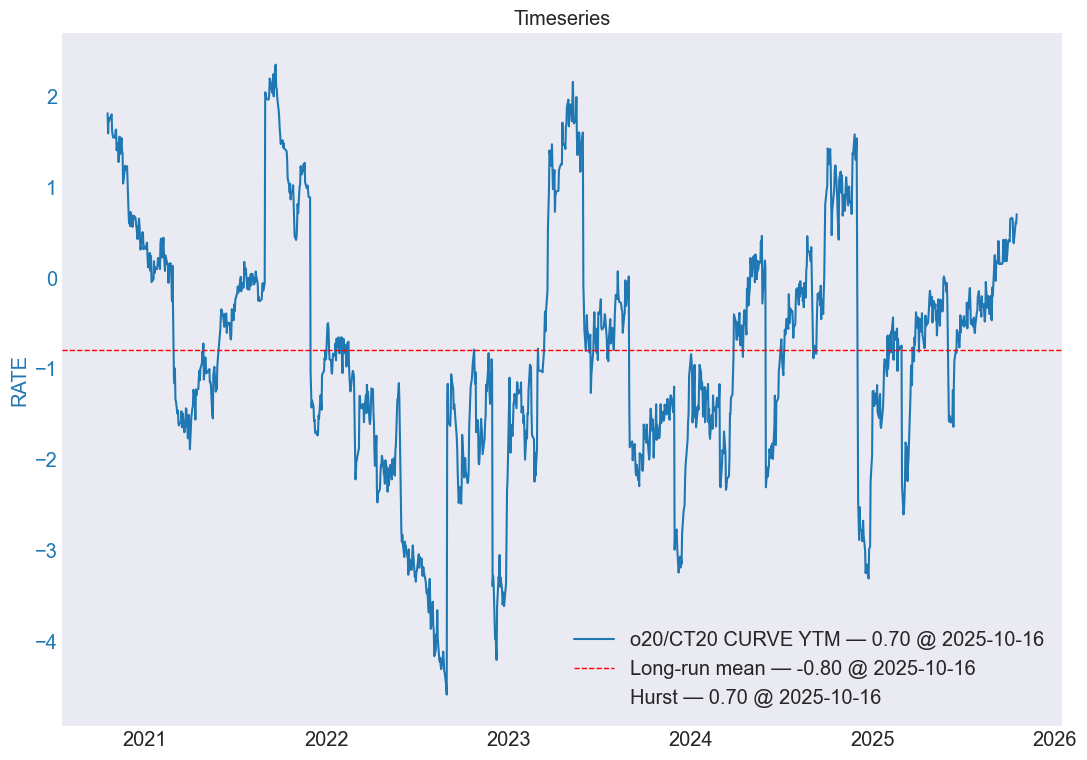

In [140]:
from RVUtils.plt_timeseries import make_secondary_axis_plot

end = datetime.date(2025, 10, 17)
start = end - datetime.timedelta(days=365 * 5) 

# q = IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT7/CT10", value=IRSwapValue.MMSS)
# q = IRSwapQuery(curve="USD-SOFR-1D", tenor="912810UA4/912810UC0", value=IRSwapValue.MMSS)
q1 = FixedRateBondQuery(cusip="o20/CT20", value=FixedRateBondValue.YTM)
# q2 = FixedRateBondQuery(cusip="CT10/CT20/CT30", value=FixedRateBondValue.YTM)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        q1, 
        # q2
    ],
    n_jobs=1,
)

plot, fig, ax, ax2, legend = make_secondary_axis_plot(ylabel_left="RATE", ylabel_right="RATE", title="Timeseries")
plot(
    # df["IRS"][q.col_name()],
    df["FRB"][q1.col_name()],
    # df["SWAPSPREADS"][q.col_name()],

    which="left",
    indicators=[
        # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        # {"kind": "ema", "window": 20, "style": {"linestyle": "--", "color": "red"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
		{"kind": "hurst", "hide": True}
    ],
    # ou={"enable": True, "steps": 90, "add_metrics_to_legend": True}
)
# plot(
# 	df["FRB"][q2.col_name()],
#     which="right",
#     indicators=[
#         {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
#         # {"kind": "ema", "window": 20, "style": {"linestyle": "--", "color": "red"}},
#         # {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
#     ],
# )

legend(show_date=True)
plt.show()


In [142]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

seasonality_df = monthend_cumsum_seasonality(df.dropna(), window=20)
display(seasonality_df)

fig = go.Figure()

# me_col = f"avg"
me_col = "avg-nov"
line_w = 1.25
min_op = 0.35
max_op = 0.85

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

n_last = 12
# monthly_cols = [c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c)]
# monthly_cols = sorted(monthly_cols)  # chronological
# keep = monthly_cols[-n_last:] if n_last > 0 else []

keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from {me_col}",
    yaxis_title="Cum Delta",
    title=f"Seasonality: template={me_col}  |  last {len(keep)} months",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True, True, True] + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True, True, True] + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})

,avg,avg-std1,avg+std1,avg-std2,avg+std2,avg-jan,avg-jan-std1,avg-jan+std1,avg-jan-std2,avg-jan+std2,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10
bdays_from_month_end,,,,,,,,,,,,,,,,,,,,,
-20,-0.003939,-1.035761,1.027883,-2.067582,2.059705,-0.057899,-0.559134,0.443336,-1.060369,0.944572,...,-0.242424,1.646805,-2.057033,0.056079,-0.090385,0.209808,-0.234795,0.052071,-0.165749,0.0
-19,-0.091795,-1.155793,0.972203,-2.219791,2.036201,0.200404,-0.207272,0.608081,-0.614948,1.015757,...,-0.410652,1.280785,-1.994896,0.0071,0.049438,-1.068617,-0.350761,-0.163841,-0.436783,0.245414
-18,-0.130589,-1.206307,0.945129,-2.282025,2.020847,0.074137,-0.223007,0.371281,-0.520152,0.668426,...,-0.272751,1.570685,-1.870155,-0.320591,-0.024098,-1.072311,-0.285149,-0.124359,-0.447991,0.262198
-17,-0.092172,-1.150686,0.966343,-2.209201,2.024858,-0.097407,-0.335382,0.140568,-0.573357,0.378543,...,-0.369263,1.657677,-1.671982,0.042809,0.011826,-1.01092,-0.085674,-0.228691,-0.232506,0.248656
-16,-0.094927,-1.15092,0.961066,-2.206914,2.017059,0.004546,-0.284854,0.293946,-0.574254,0.583346,...,-0.38929,1.459885,-1.263605,-0.060502,-0.161595,-1.037788,-0.36869,-0.004578,-0.252724,0.24773
-15,-0.106022,-1.186824,0.97478,-2.267627,2.055583,0.009637,-0.333335,0.352608,-0.676306,0.69558,...,-0.179482,1.68705,-1.325989,-0.103188,-0.069427,-1.082802,-0.113106,-0.123413,-0.008583,0.010199
-14,-0.113751,-1.1685,0.940998,-2.223248,1.995746,-0.158268,-0.368607,0.052071,-0.578945,0.262409,...,-0.478172,1.669291,-1.689339,0.101662,-0.331497,-1.039505,-0.154877,-0.090639,-0.019073,-0.018563
-13,-0.077504,-1.102656,0.947648,-2.127808,1.9728,-0.104604,-0.441659,0.232451,-0.778714,0.569507,...,-0.541115,1.846886,-1.527405,-0.14252,0.066948,-0.725174,0.075531,-0.203514,-0.264931,0.21318
-12,-0.110083,-1.132677,0.91251,-2.155271,1.935104,-0.105498,-0.371654,0.160657,-0.637809,0.426812,...,-0.32891,1.380157,-1.438727,-0.169373,-0.031853,-1.129532,-0.082177,-0.282374,-0.254719,0.199776
